In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


data = pd.read_csv("data/FRED data.csv", encoding="utf-8-sig")

data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")

In [2]:
#EDA
data.info()
data.describe()
data.isnull().sum()
data["recession"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   410 non-null    datetime64[ns]
 1   unemployment           410 non-null    float64       
 2   cpi                    410 non-null    float64       
 3   industrial_production  410 non-null    float64       
 4   retail_sales           410 non-null    int64         
 5   consumer_sentiment     410 non-null    float64       
 6   recession              410 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 22.6 KB


recession
0    382
1     28
Name: count, dtype: int64

In [3]:
#Feature Engineering
feature_cols = ["unemployment", "cpi", "industrial_production", "retail_sales", "consumer_sentiment"]

#Lag
for col in feature_cols:
    data[f"{col}_lag1"] = data[col].shift(1)
    data[f"{col}_lag3"] = data[col].shift(3)
    data[f"{col}_lag6"] = data[col].shift(6)

for col in feature_cols:
    data[f"{col}_change"] = data[col].pct_change()

data = data.dropna()

In [4]:
#Training Models
X = data.drop(columns=["date", "recession"])
y = data["recession"]


split = int(len(data) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

lr_smote = LogisticRegression(max_iter=5000)
lr_smote.fit(X_train_smote_scaled, y_train_smote)
lr_smote_pred = lr_smote.predict(X_test_scaled)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
rf_smote_pred = rf_smote.predict(X_test)

gb_smote = GradientBoostingClassifier(random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
gb_smote_pred = gb_smote.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, lr_smote_pred, zero_division=0))

print("Random Forest")
print(classification_report(y_test, rf_smote_pred, zero_division=0))

print("Gradient Boosting")
print(classification_report(y_test, gb_smote_pred, zero_division=0))

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "C:\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Python313\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 187: character maps to <undefined>


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        79
           1       0.13      1.00      0.24         2

    accuracy                           0.84        81
   macro avg       0.57      0.92      0.57        81
weighted avg       0.98      0.84      0.89        81

Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        79
           1       0.00      0.00      0.00         2

    accuracy                           0.98        81
   macro avg       0.49      0.50      0.49        81
weighted avg       0.95      0.98      0.96        81

Gradient Boosting
              precision    recall  f1-score   support

           0       0.93      0.35      0.51        79
           1       0.00      0.00      0.00         2

    accuracy                           0.35        81
   macro avg       0.47      0.18      0.26        81
weighted avg       0.9


Logistic Regression (threshold=0.3)
Accuracy: 0.7530864197530864
Precision: 0.09090909090909091
Recall: 1.0
F1 Score: 0.16666666666666666
ROC-AUC: 1.0

Random Forest (threshold=0.3)
Accuracy: 0.7901234567901234
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.31012658227848106

Gradient Boosting (threshold=0.3)
Accuracy: 0.32098765432098764
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.18987341772151894

Logistic Regression (threshold=0.3)
[[59 20]
 [ 0  2]]

Random Forest (threshold=0.3)
[[64 15]
 [ 2  0]]

Gradient Boosting (threshold=0.3)
[[26 53]
 [ 2  0]]


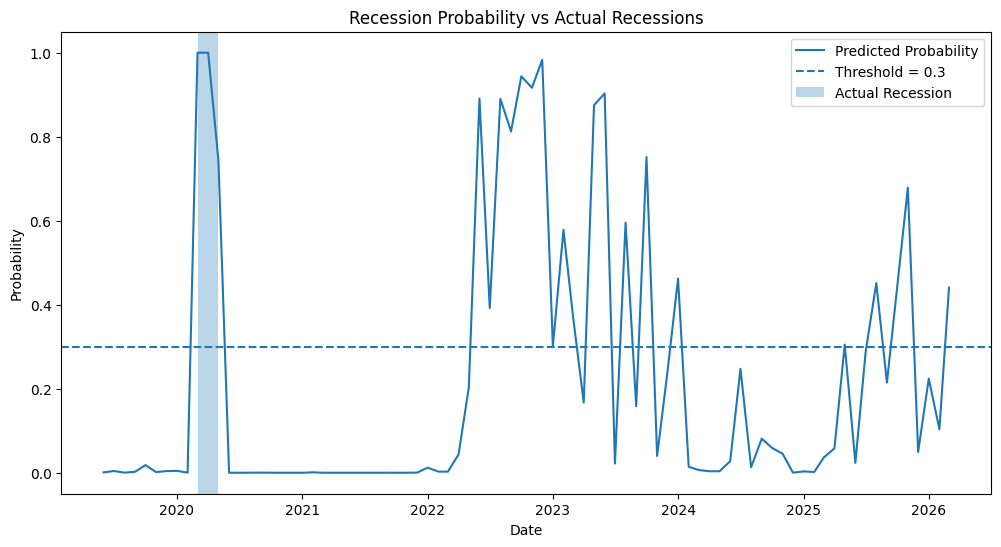

In [5]:
#Evaluation
def evaluate_model_threshold(name, model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    print(f"\n{name} (threshold={threshold})")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

evaluate_model_threshold("Logistic Regression", lr_smote, X_test_scaled, y_test, 0.3)
evaluate_model_threshold("Random Forest", rf_smote, X_test, y_test, 0.3)
evaluate_model_threshold("Gradient Boosting", gb_smote, X_test, y_test, 0.3)

def show_confusion_threshold(name, model, X_test, y_test, threshold=0.3):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > threshold).astype(int)

    print(f"\n{name} (threshold={threshold})")
    print(confusion_matrix(y_test, y_pred))


show_confusion_threshold("Logistic Regression", lr_smote, X_test_scaled, y_test, 0.3)
show_confusion_threshold("Random Forest", rf_smote, X_test, y_test, 0.3)
show_confusion_threshold("Gradient Boosting", gb_smote, X_test, y_test, 0.3)

probs = lr_smote.predict_proba(X_test_scaled)[:, 1]
threshold = 0.3

dates = data["date"].iloc[-len(probs):].reset_index(drop=True)
actual = y_test.reset_index(drop=True)

plt.figure(figsize=(12,6))
plt.plot(dates, probs, label="Predicted Probability")
plt.axhline(y=threshold, linestyle="--", label="Threshold = 0.3")
in_recession = False

for i in range(len(actual)):
    if actual[i] == 1 and not in_recession:
        start = dates[i]
        in_recession = True
    elif actual[i] == 0 and in_recession:
        end = dates[i]
        plt.axvspan(start, end, alpha=0.3, label="Actual Recession" if 'Actual Recession' not in plt.gca().get_legend_handles_labels()[1] else "")
        in_recession = False

if in_recession:
    plt.axvspan(start, dates.iloc[-1], alpha=0.3, label="Actual Recession")

plt.title("Recession Probability vs Actual Recessions")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.show()